In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from torch.utils.data import DataLoader,TensorDataset

/home/anmino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv(r"train.csv")

In [3]:
df = df.drop("id",axis=1)

In [4]:
ohe = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
encoded = ohe.fit_transform(df[["Sex"]])

In [5]:
encoded_col_name = ohe.get_feature_names_out()
encoded_col_name

array(['Sex_male'], dtype=object)

In [6]:
encoded_df = pd.DataFrame(encoded,columns=encoded_col_name)

In [7]:
final_df = pd.concat(
    [df.drop("Sex",axis=1),encoded_df],
    axis=1
)

In [8]:
x = final_df.drop("Calories",axis=1).values
y = final_df["Calories"].values

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_train_y_test_scaler = StandardScaler()
y_train = y_train_y_test_scaler.fit_transform(y_train.reshape(-1,1))
y_test = y_train_y_test_scaler.transform(y_test.reshape(-1,1))

In [11]:
joblib.dump(ohe,filename="OneHotEncoder.pkl")
joblib.dump(scaler,filename="x_train_x_test_scaler.pkl")
joblib.dump(y_train_y_test_scaler,filename="y_train_y_test_scaler.pkl")

['y_train_y_test_scaler.pkl']

In [12]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [13]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

test_dataset = TensorDataset(
    x_test,
    y_test
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False
)

In [128]:
class GELUBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(dim,dim),
            nn.BatchNorm1d(dim),
            nn.GELU()
        )

        self.fc2 = nn.Sequential(
            nn.Linear(dim,dim),
            nn.BatchNorm1d(dim),
            nn.GELU()
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        information = self.fc1(x)

        out = self.fc2(x)

        out = self.sigmoid(out)

        out = out * information
        return out


class FeatureExtractionBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.fc1 = nn.Linear(dim,dim)
        self.batch1 = nn.BatchNorm1d(dim)
        self.gelu1 = nn.GELU()

        self.fc2 = nn.Linear(dim,dim)
        self.batch2 = nn.BatchNorm1d(dim)


        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        out = self.fc1(x)

        out = self.batch1(out)

        out = self.gelu1(out)

        out = self.fc2(out)
        out = self.batch2(out)

        attention = self.sigmoid(out)

        out = x * attention

        return out


class CrossLayerBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(dim)
        )
        self.bias = nn.Parameter(
            torch.zeros(dim)
        )

    def forward(self,x0,x):
        weighted = x* self.weight

        cross = torch.sum(
            weighted,
            dim=1,
            keepdim=True
        )

        out = x0 * cross
        out = out + self.bias
        out = out + x
        return out

class CrossNetworkBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.cross1 = CrossLayerBlock(dim=dim)
        self.cross2 = CrossLayerBlock(dim=dim)
        self.cross3 = CrossLayerBlock(dim=dim)

    def forward(self,x):
        information = x
        out = self.cross1(information,x)
        out = self.cross2(information,out)
        out = self.cross3(information,out)
        return out

class DeepNetwork(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.fc1 = nn.Sequential(
                    nn.Linear(input_dim,128),
                    nn.BatchNorm1d(128),
                    nn.GELU(),
                    nn.Dropout(0.2),
        
                    nn.Linear(128,64),
                    nn.BatchNorm1d(64),
                    nn.GELU(),
                    nn.Dropout(0.2),
        
                    nn.Linear(64,32),
                    nn.BatchNorm1d(32),
                    nn.GELU(),
                    nn.Dropout(0.1)
                )
    def forward(self,x):
        return self.fc1(x)
         

class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.cross_net = CrossNetworkBlock(dim=input_dim)
        self.deep_net = DeepNetwork(input_dim=input_dim)
        self.gelu = GELUBlock(dim=input_dim + 32)
        self.attention = FeatureExtractionBlock(dim=input_dim + 32)

        self.output = nn.Linear(input_dim + 32,1)

    def forward(self,x):
        cross = self.cross_net(x)
        deep = self.deep_net(x)

        out = torch.cat(
            [cross,deep],
            dim=1
        )

        out = self.gelu(out)
        out = self.attention(out)
        return self.output(out)
        

In [129]:
"""class CrossLayer(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(dim))

        self.bias = nn.Parameter(torch.zeros(dim))

    def forward(self,x0,x):
        weighted = x

        cross = torch.sum(
            weighted,dim=1,keepdim=True
        )

        out = x0 * cross
        out = out * self.bias
        out = out * x
        return out

class CrossNetwork(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.cross1 = CrossLayer(dim=input_dim)
        self.cross2 = CrossLayer(dim=input_dim)
        self.cross3 = CrossLayer(dim=input_dim)
        self.cross4 = CrossLayer(dim=input_dim)

    def forward(self,x):
        x0 = x

        out = self.cross1(x0,x)
        out = self.cross2(x0,x)
        out = self.cross3(x0,x)
        out = self.cross4(x0,x)
        return out




class FeatureExtraction(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(input_dim,input_dim),
            nn.ReLU(),
            nn.Linear(input_dim,input_dim),
            nn.ReLU(),
            nn.Sigmoid()
        )

    def forward(self,x):
        return x * self.attention(x)

class ResidualBlock(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,input_dim),
            nn.LayerNorm(input_dim),
            nn.ReLU()
        )


        self.fc2 = nn.Sequential(
            nn.Linear(input_dim,input_dim),
            nn.LayerNorm(input_dim),
            nn.ReLU(), 
        )

    def forward(self,x):
        idi = x

        out = self.fc1(x)
        out = self.fc2(out)

        out = out + idi

        return out


class DeepNetwork(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64,32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.residual = ResidualBlock(input_dim=32)

    def forward(self,x):
        out = self.fc1(x)
        out = self.residual(out)
        return out


# final combine model

class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.cross_network = CrossNetwork(input_dim=input_dim)

        self.deep_network = DeepNetwork(input_dim=input_dim)
        combined_dim = input_dim + 32
        self.attention = FeatureExtraction(input_dim=combined_dim)

        self.output = nn.Linear(combined_dim,1)

    def forward(self,x):
        cross = self.cross_network(x)
        deep = self.deep_network(x)

        out = torch.cat(
            [cross,deep],
            dim=1
        )

        out = self.attention(out)
        out = self.output(out)
        return out

"""

'class CrossLayer(nn.Module):\n    def __init__(self,dim):\n        super().__init__()\n\n        self.weight = nn.Parameter(torch.randn(dim))\n\n        self.bias = nn.Parameter(torch.zeros(dim))\n\n    def forward(self,x0,x):\n        weighted = x\n\n        cross = torch.sum(\n            weighted,dim=1,keepdim=True\n        )\n\n        out = x0 * cross\n        out = out * self.bias\n        out = out * x\n        return out\n\nclass CrossNetwork(nn.Module):\n    def __init__(self,input_dim):\n        super().__init__()\n\n        self.cross1 = CrossLayer(dim=input_dim)\n        self.cross2 = CrossLayer(dim=input_dim)\n        self.cross3 = CrossLayer(dim=input_dim)\n        self.cross4 = CrossLayer(dim=input_dim)\n\n    def forward(self,x):\n        x0 = x\n\n        out = self.cross1(x0,x)\n        out = self.cross2(x0,x)\n        out = self.cross3(x0,x)\n        out = self.cross4(x0,x)\n        return out\n\n\n\n\nclass FeatureExtraction(nn.Module):\n    def __init__(self,input

In [130]:

"""class CrossLayer(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(dim)
        )
        self.bias = nn.Parameter(
            torch.zeros(dim)
        )

    def forward(self,x0,x):
        weighted = x

        cross = torch.sum(
            weighted,
            dim=1,
            keepdim=True
        )

        out = x0 * cross

        out = out * self.bias

        out = out * x
        return out


class CrossNetwork(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.cross1 = CrossLayer(dim=input_dim)
        self.cross2 = CrossLayer(dim=input_dim)
        self.cross3 = CrossLayer(dim=input_dim)
        self.cross4 = CrossLayer(dim=input_dim)

    def forward(self,x):
        x0 = x
        out = self.cross1(x0,x)
        out = self.cross2(x0,x)
        out = self.cross3(x0,x)
        out = self.cross4(x0,x)
        return out


class DeepNetwork(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,512),
            nn.BatchNorm1d(512),
            nn.GELU(),

            nn.Linear(512,256),
            nn.BatchNorm1d(256),
            nn.GELU(),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.GELU(),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.GELU(),
        )

    def forward(self,x):
        return self.fc1(x)


class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.cross_net = CrossNetwork(input_dim=input_dim)
        self.deep_nt = DeepNetwork(input_dim=input_dim)

        self.output = nn.Linear(input_dim + 32,1)

    def forward(self,x):
        cross = self.cross_net(x)
        deep = self.deep_nt(x)

        out = torch.cat(
            [cross,deep],
            dim=1,
        )

        output = self.output(out)
        return output"""

'class CrossLayer(nn.Module):\n    def __init__(self,dim):\n        super().__init__()\n\n        self.weight = nn.Parameter(\n            torch.randn(dim)\n        )\n        self.bias = nn.Parameter(\n            torch.zeros(dim)\n        )\n\n    def forward(self,x0,x):\n        weighted = x\n\n        cross = torch.sum(\n            weighted,\n            dim=1,\n            keepdim=True\n        )\n\n        out = x0 * cross\n\n        out = out * self.bias\n\n        out = out * x\n        return out\n\n\nclass CrossNetwork(nn.Module):\n    def __init__(self,input_dim):\n        super().__init__()\n\n        self.cross1 = CrossLayer(dim=input_dim)\n        self.cross2 = CrossLayer(dim=input_dim)\n        self.cross3 = CrossLayer(dim=input_dim)\n        self.cross4 = CrossLayer(dim=input_dim)\n\n    def forward(self,x):\n        x0 = x\n        out = self.cross1(x0,x)\n        out = self.cross2(x0,x)\n        out = self.cross3(x0,x)\n        out = self.cross4(x0,x)\n        return

In [131]:
256/2

128.0

In [132]:
dcn_model = MyModel(7)
dcn_model.training

True

In [133]:
loss_function = nn.MSELoss()
optimizer_function = torch.optim.AdamW(dcn_model.parameters(),lr=0.001,weight_decay=0.01)

In [134]:
train_loss_hist = []
test_loss_hist = []

epochs = 60
progress_bar = tqdm(range(epochs),colour="red",desc="Ann_Model")
for i in progress_bar:
    dcn_model.train()
    total_train_loss = 0

    for x_batch,y_batch in train_loader:
        optimizer_function.zero_grad()
        prediction = dcn_model(x_batch)
        loss = loss_function(prediction,y_batch)
        loss.backward()
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    dcn_model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for x_test,y_test in test_loader:
            test_prediction = dcn_model(x_test)
            test_loss = loss_function(test_prediction,y_test)
            total_test_loss += test_loss.item()

        avg_test_loss = total_test_loss / len(test_loader)
        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epochs":epochs,
            "Train_Loss":avg_train_loss,
            "Test_Loss":avg_test_loss,
            "Optimizer":optimizer_function.state_dict()
        },f"SEBlock/checkpoint_{i}.pth")

        progress_bar.set_postfix({
            "Epoch":i,
            "Tain_Loss":f"{avg_train_loss:.4f}",
            "Test_Loss":f"{avg_test_loss:.4f}"
        })


Ann_Model: 100%|██████████| 60/60 [36:12<00:00, 36.21s/it, Epoch=59, Tain_Loss=0.0038, Test_Loss=0.0037]


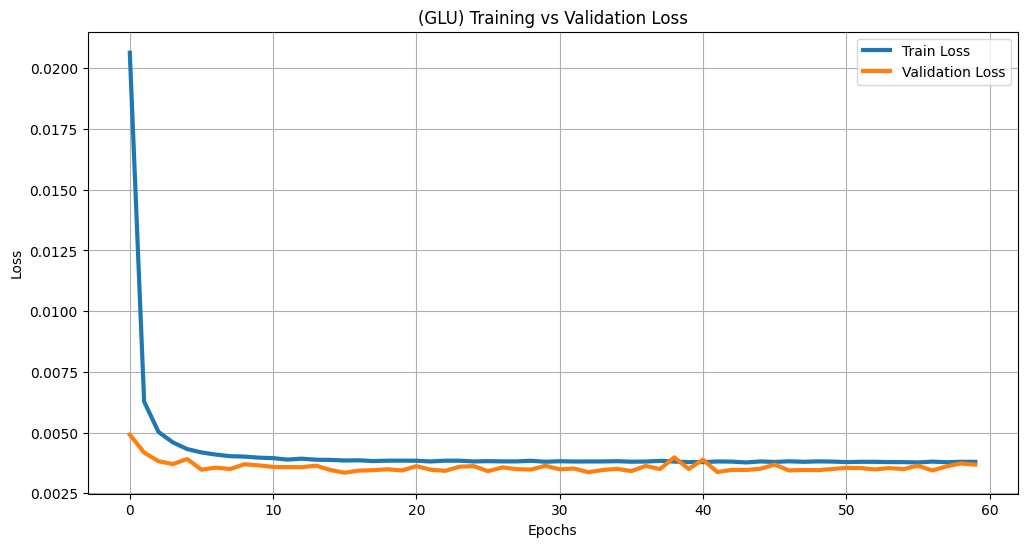

In [135]:
plt.figure(figsize=(12,6))

plt.plot(
    
    train_loss_hist,
    
    label="Train Loss",linewidth=3
)

plt.plot(
    
    test_loss_hist,
    
    label="Validation Loss",linewidth=3
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("(GLU) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

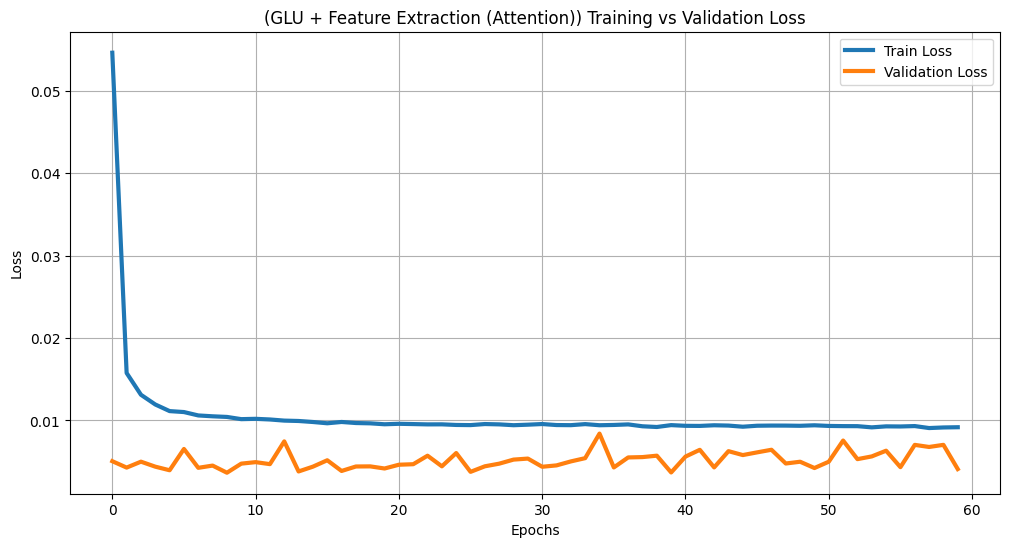

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    
    train_loss_hist,
    
    label="Train Loss",linewidth=3
)

plt.plot(
    
    test_loss_hist,
    
    label="Validation Loss",linewidth=3
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("(GLU + Feature Extraction (Attention)) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

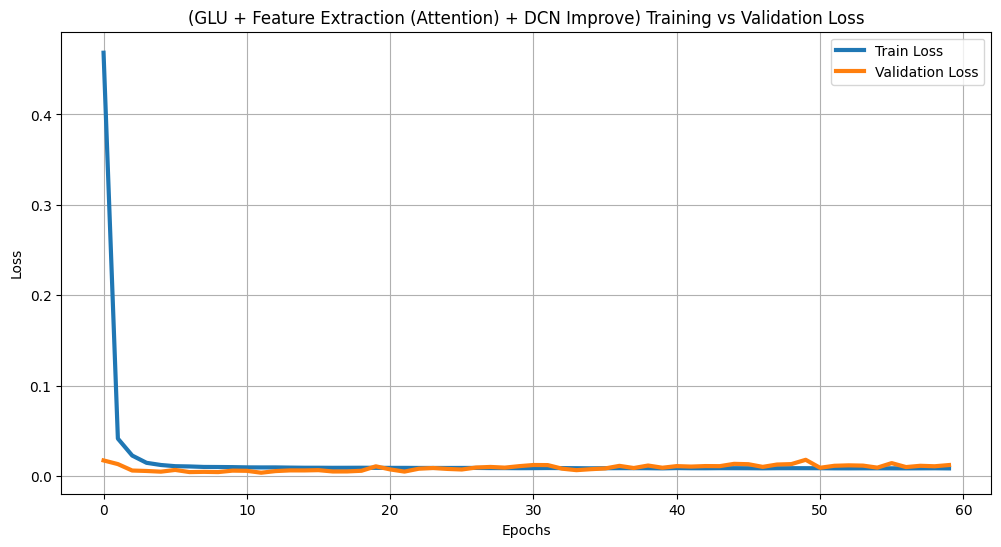

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    
    train_loss_hist,
    
    label="Train Loss",linewidth=3
)

plt.plot(
    
    test_loss_hist,
    
    label="Validation Loss",linewidth=3
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("(GLU + Feature Extraction (Attention) + DCN Improve) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()